# **Import Libraries and Dataset**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
import warnings
warnings.filterwarnings('ignore')


In [2]:
sales_train_df = pd.read_csv('train.csv')
store_df = pd.read_csv('store.csv')

In [3]:
sales_train_df.head()

# 1115 unique stores
# Note that sales is the target variable (that's what we are trying to predict)

# Id: transaction ID (combination of Store and date)
# Store: unique store Id
# Sales: sales/day, this is the target variable
# Customers: number of customers on a given day
# Open: Boolean to say whether a store is open or closed (0 = closed, 1 = open)
# Promo: describes if store is running a promo on that day or not
# StateHoliday: indicate which state holiday (a = public holiday, b = Easter holiday, c = Christmas, 0 = None)
# SchoolHoliday: indicates if the (Store, Date) was affected by the closure of public schools

#- Data Source: https://www.kaggle.com/c/rossmann-store-sales/data



,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [4]:
sales_train_df.info()
#we have  1017209 observations and 9 columns, 8 features and 1 target(Sales)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [5]:
sales_train_df.describe()

#Average number of customers per day is approximately 633, with minimum 0 and maximum 738
#Average sales per day is approximately 5773, with minimum 0 and maximum 41551


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [6]:
store_df.head()

#Store - a unique Id for each store
#StoreType - differentiates between 4 different store models: a, b, c, d
#Assortment - describes an assortment level: a = basic, b = extra, c = extended
#CompetitionDistance - distance in meters to the nearest competitor store
#CompetitionOpenSinceMonth - gives the approximate month of the time the nearest competitor was opened
#CompetitionOpenSince Year - gives the approximate year  of the time the nearest competitor was opened
#Promo - indicates whether a store is running a promo on that day
#Promo2 - Promo2 is a continuing and consecutive promotion for some stores: 0 = store is not participating, 1 = store is participating
#Promo2Since Week - describes the calendar week when the store started participating in Promo2
#Promo2Since Year - describes the year week when the store started participating in Promo2
#PromoInterval - describes the consecutive intervals Promo2 is started, naming the months the promotion is started anew. E.g. "Feb,May,Aug,Nov" means each round starts in February, May, August, November of any given year for that store

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [7]:
store_df.info()
# The dataset includes 1115 unique stores with 10 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [8]:
store_df.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


# **Explore Dataset**

## Explote Sales Data

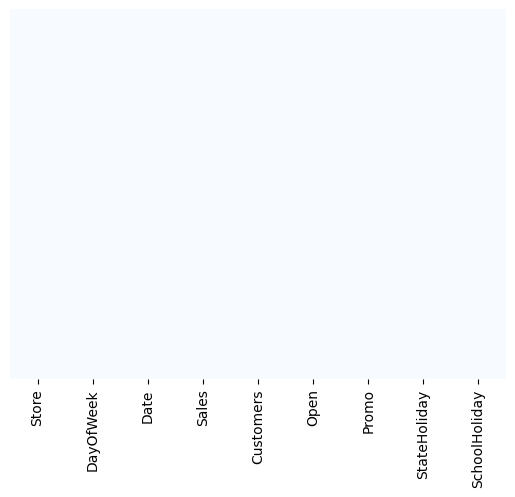

In [9]:
sns.heatmap(sales_train_df.isnull(), cmap='Blues',yticklabels=False, cbar=False)
plt.show()

In [10]:
sales_train_df.isnull().sum()
#Confirming there is no null value in our sales_train dataset

Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
dtype: int64

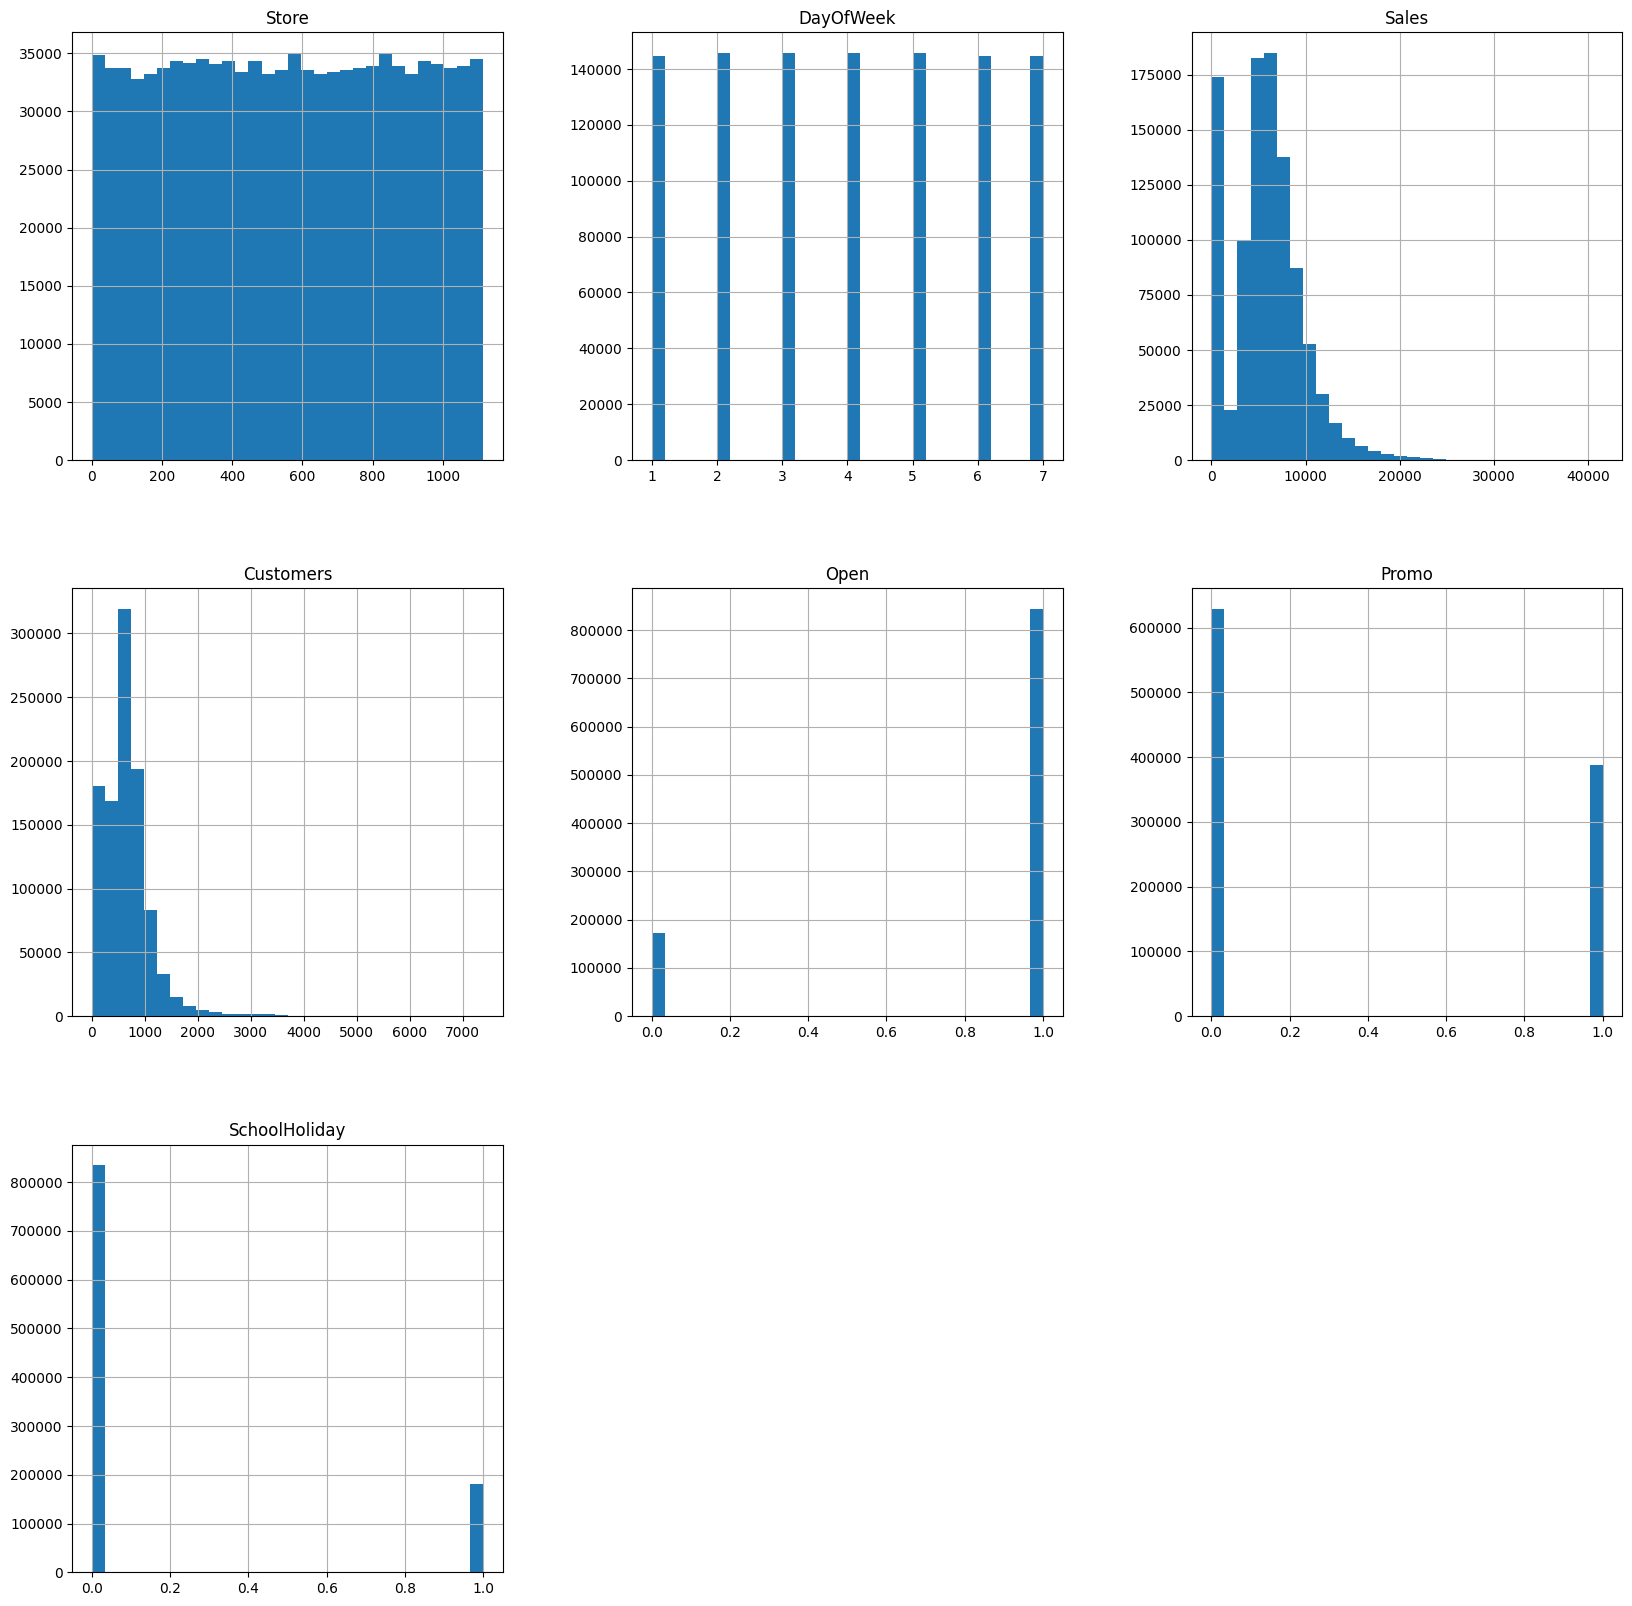

In [11]:

sales_train_df.hist(bins = 30, figsize = (20,20))
plt.show()
# Average 600 customers per day, maximum is 4500 (note that we can't see the outlier at 7388!)
# Data is equally distibuted across various Days of the week (~150000 observations x 7 day = ~1.1 million observation)
# Stores are open ~80% of the time
# Data is equally distributed among all stores (no bias)
# Promo #1 was running ~40% of the time
# Average sales around 5000-6000 Euros
# School holidays are around ~18% of the time

In [12]:

# Count the number of open and closed stores
print(f"Total number of stores: {len(sales_train_df.Open)}")
print(f"Total number of open stores: {len(sales_train_df.Open[sales_train_df.Open == 1])}")
print(f"Total number of closed stores: {len(sales_train_df.Open[sales_train_df.Open == 0])}")

Total number of stores: 1017209
Total number of open stores: 844392
Total number of closed stores: 172817


In [13]:
# Only keep the open store
sales_train_df = sales_train_df[sales_train_df.Open == 1]
sales_train_df.shape

(844392, 9)

In [14]:
# Drop the Open column
sales_train_df.drop(['Open'], axis = 1, inplace = True)
sales_train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,0,1
1,2,5,2015-07-31,6064,625,1,0,1
2,3,5,2015-07-31,8314,821,1,0,1
3,4,5,2015-07-31,13995,1498,1,0,1
4,5,5,2015-07-31,4822,559,1,0,1


## Explore Stores Data

In [15]:
sales_train_df.describe()
# Average sales for open stores = 6955
# Average number of customers for open stores = 762

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000


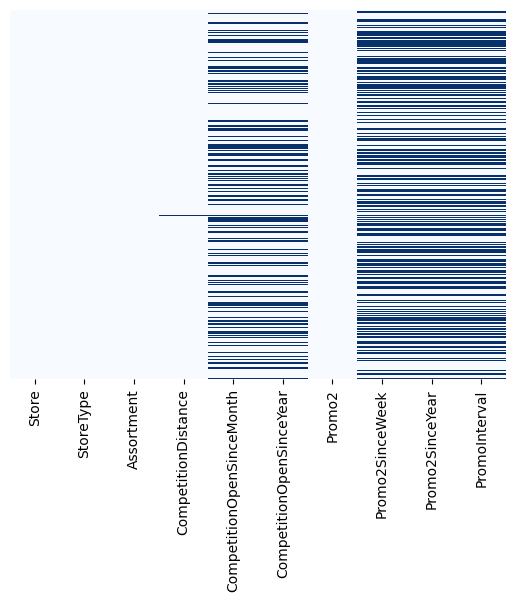

In [16]:
# Looking for missing values in store data
sns.heatmap(store_df.isnull(), cmap='Blues',yticklabels=False, cbar=False)
plt.show()

In [17]:
store_df.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [18]:
# Let's look at the missing values in the 'CompetitionDistance'
store_df[store_df['CompetitionDistance'].isnull()]

# Only 3 missing values in 1115 rows

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [19]:
# Let's look at the missing values in the 'CompetitionOpenSinceMonth'
store_df[store_df['CompetitionOpenSinceMonth'].isnull()]
# 354 rows are missing in 1115 rows

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [20]:
store_df.Promo2.value_counts()

Promo2
1    571
0    544
Name: count, dtype: int64

In [21]:
store_df[ store_df['Promo2'] == 0]


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1107,1108,a,a,540.0,4.0,2004.0,0,NaN,NaN,NaN
1109,1110,c,c,900.0,9.0,2010.0,0,NaN,NaN,NaN
1111,1112,c,c,1880.0,4.0,2006.0,0,NaN,NaN,NaN
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN


In [22]:
# It seems like when 'Promo2' is 0 (for 544 rows) columns 'Promo2SinceWeek', 'Promo2SinceYear' and 'PromoInterval' have missing values
# There are 354 rows where 'CompetitionOpenSinceMonth' and 'CompetitionOpenSinceYear' with missing values
# We set all those missing values to zero


cols = [ 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval','CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', ]

for col in cols:
  store_df[col].fillna(0, inplace = True)

In [23]:
store_df.isnull().sum()
# We still have 3 missing values in CompetitionDistance

Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          3
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [24]:
# We fill the 3 missing values for the 'CompetitionDistance' with its mean
store_df['CompetitionDistance'].fillna(store_df['CompetitionDistance'].mean(), inplace = True)

In [25]:
store_df.isnull().sum()


Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

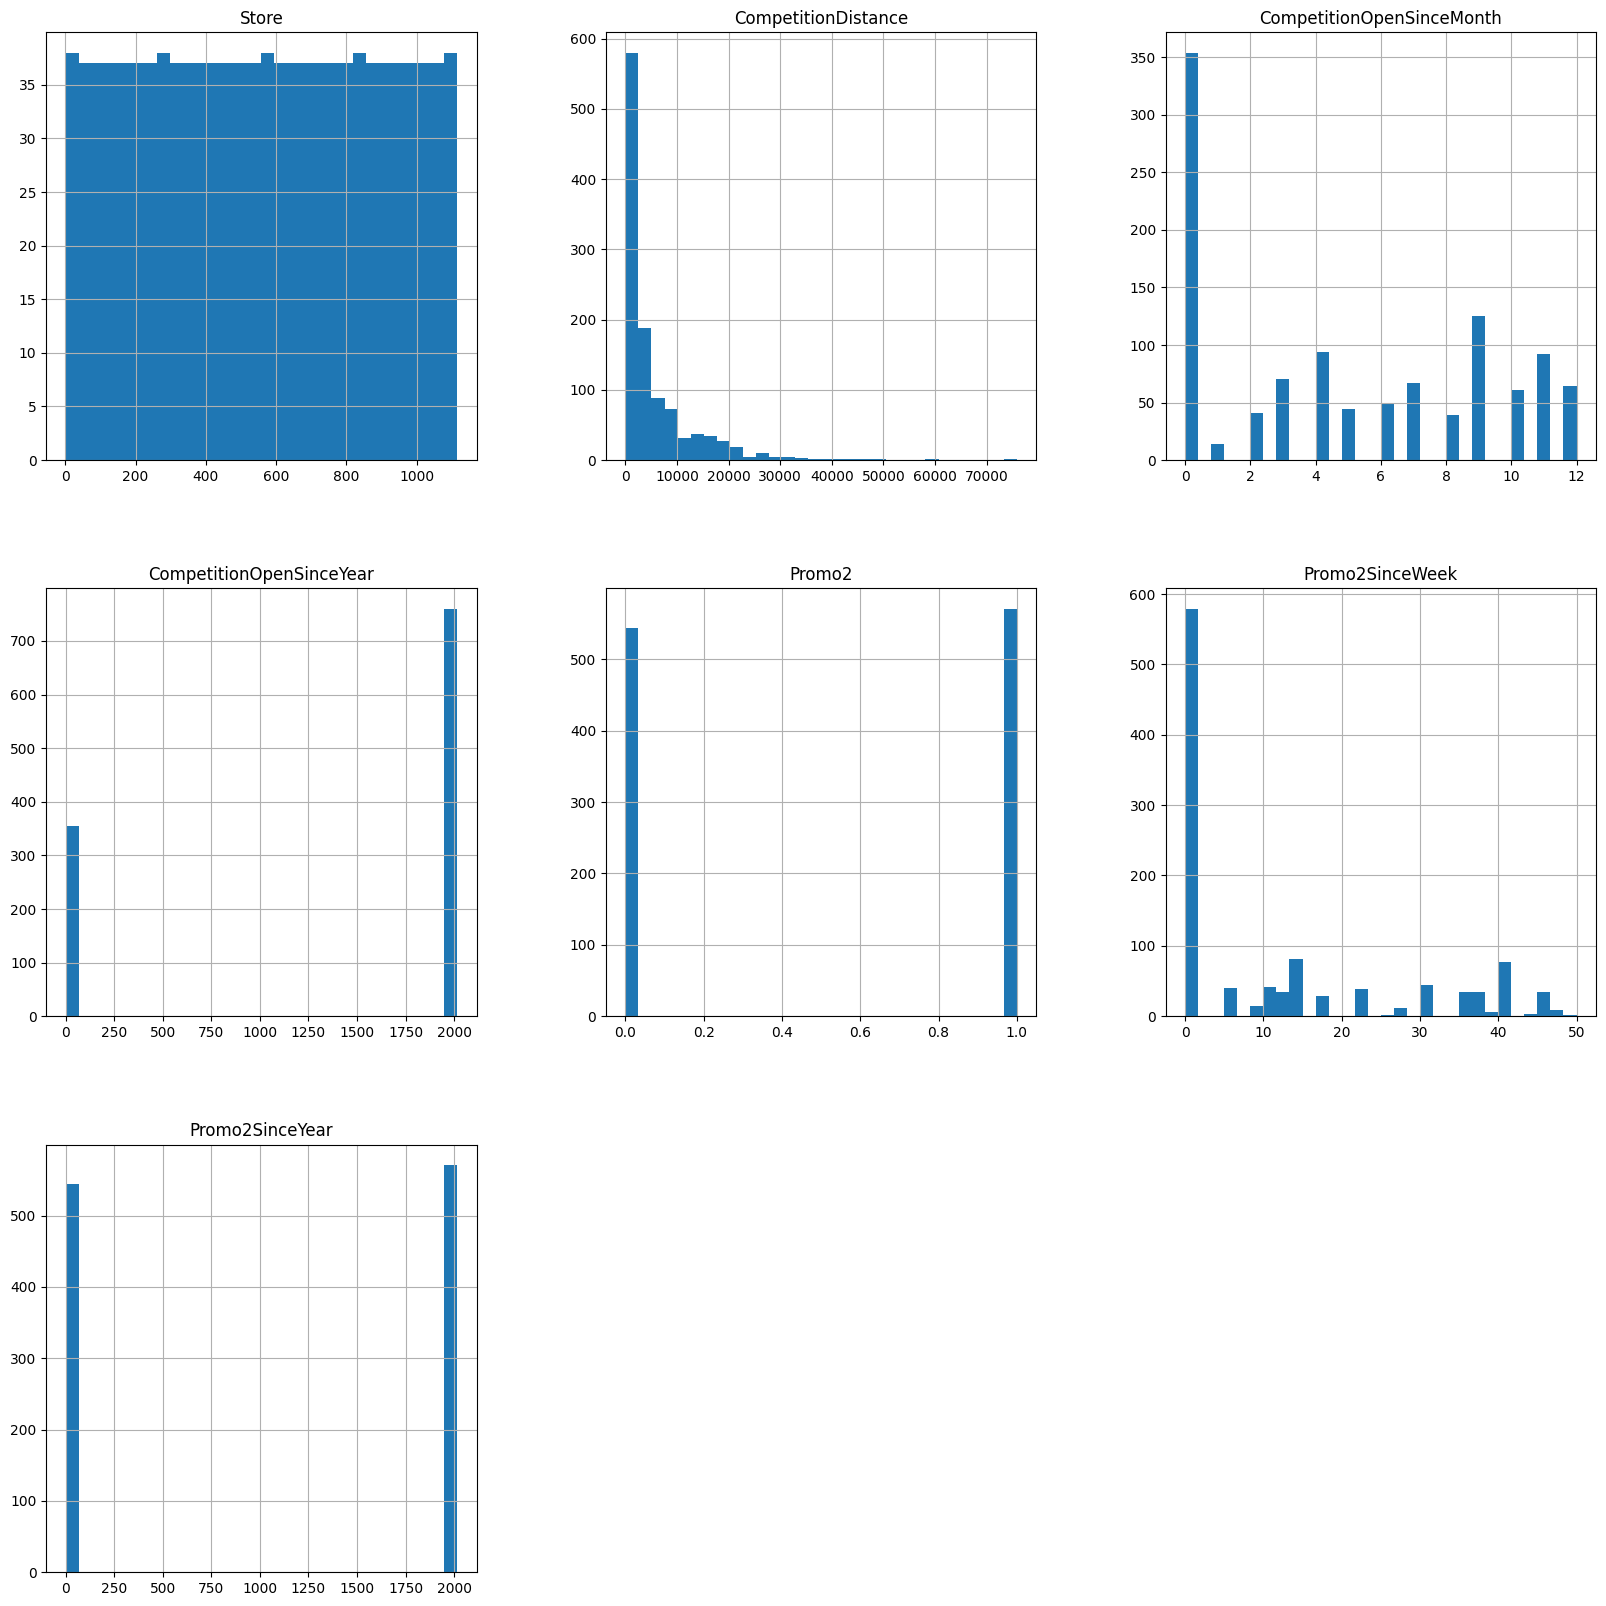

In [26]:
store_df.hist(bins = 30, figsize = (20,20))
plt.show()

In [27]:
sales_store_df = pd.merge(sales_train_df, store_df, on = 'Store', how = 'inner')
sales_store_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0


In [28]:
sales_store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844392 entries, 0 to 844391
Data columns (total 17 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Store                      844392 non-null  int64  
 1   DayOfWeek                  844392 non-null  int64  
 2   Date                       844392 non-null  object 
 3   Sales                      844392 non-null  int64  
 4   Customers                  844392 non-null  int64  
 5   Promo                      844392 non-null  int64  
 6   StateHoliday               844392 non-null  object 
 7   SchoolHoliday              844392 non-null  int64  
 8   StoreType                  844392 non-null  object 
 9   Assortment                 844392 non-null  object 
 10  CompetitionDistance        844392 non-null  float64
 11  CompetitionOpenSinceMonth  844392 non-null  float64
 12  CompetitionOpenSinceYear   844392 non-null  float64
 13  Promo2                     84

In [29]:
sales_store_df.describe()

,Store,DayOfWeek,Sales,Customers,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000,844392.000000
mean,558.422920,3.520361,6955.514291,762.728395,0.446352,0.193580,5457.842215,4.926491,1369.688401,0.498684,11.596118,1003.230065
std,321.731914,1.723689,3104.214680,401.227674,0.497114,0.395103,7799.322503,4.283663,935.558173,0.499999,15.307873,1005.874806
min,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,280.000000,2.000000,4859.000000,519.000000,0.000000,0.000000,710.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,558.000000,3.000000,6369.000000,676.000000,0.000000,0.000000,2330.000000,4.000000,2006.000000,0.000000,0.000000,0.000000
75%,837.000000,5.000000,8360.000000,893.000000,1.000000,0.000000,6880.000000,9.000000,2011.000000,1.000000,22.000000,2012.000000
max,1115.000000,7.000000,41551.000000,7388.000000,1.000000,1.000000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [30]:
sales_store_df.to_csv('sales_store_df.csv', index = False)

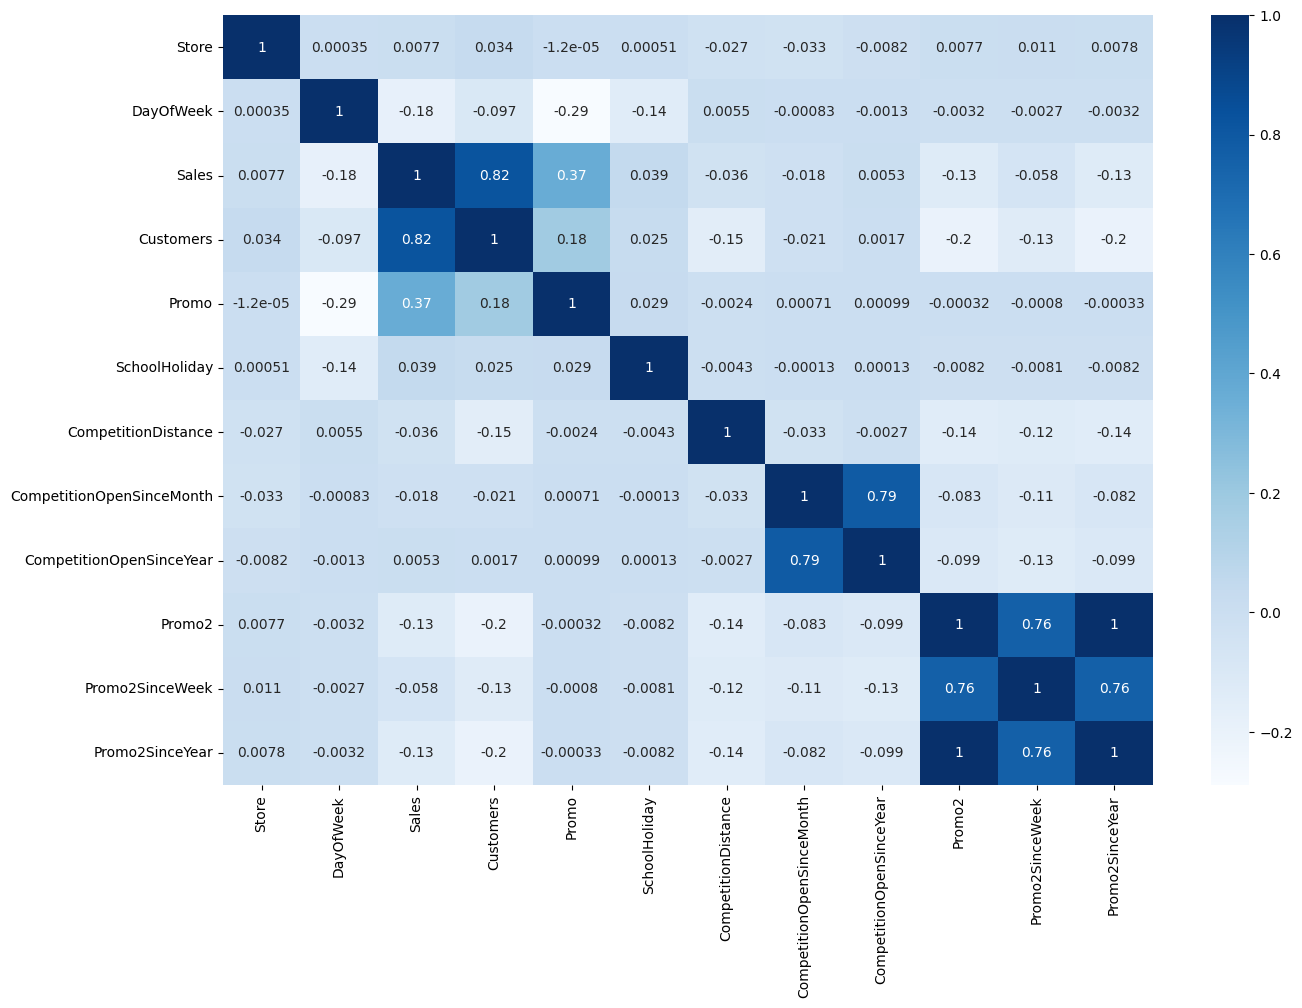

In [31]:
from matplotlib import cm
correlation = sales_store_df.corr(numeric_only=True)
plt.figure(figsize = (15,10))
sns.heatmap(correlation, annot = True, cmap = "Blues")
plt.show()


In [32]:
correlation['Sales'].sort_values(ascending=False)
# Sales have strong correlation with Customers and Moderate correlation with Promo but not Promo2

Sales                        1.000000
Customers                    0.823597
Promo                        0.368145
SchoolHoliday                0.038617
Store                        0.007710
CompetitionOpenSinceYear     0.005266
CompetitionOpenSinceMonth   -0.018370
CompetitionDistance         -0.036343
Promo2SinceWeek             -0.058476
Promo2                      -0.127596
Promo2SinceYear             -0.127621
DayOfWeek                   -0.178736
Name: Sales, dtype: float64

In [33]:
# Let's separate the year and put it into a separate column
sales_store_df['Year'] = pd.DatetimeIndex(sales_store_df['Date']).year
sales_store_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015


In [34]:
sales_store_df['Month'] = pd.DatetimeIndex(sales_store_df['Date']).month
sales_store_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7


In [35]:
sales_store_df['Day'] = pd.DatetimeIndex(sales_store_df['Date']).day
sales_store_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31
2,3,5,2015-07-31,8314,821,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct",2015,7,31
3,4,5,2015-07-31,13995,1498,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,0,2015,7,31
4,5,5,2015-07-31,4822,559,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,0,2015,7,31


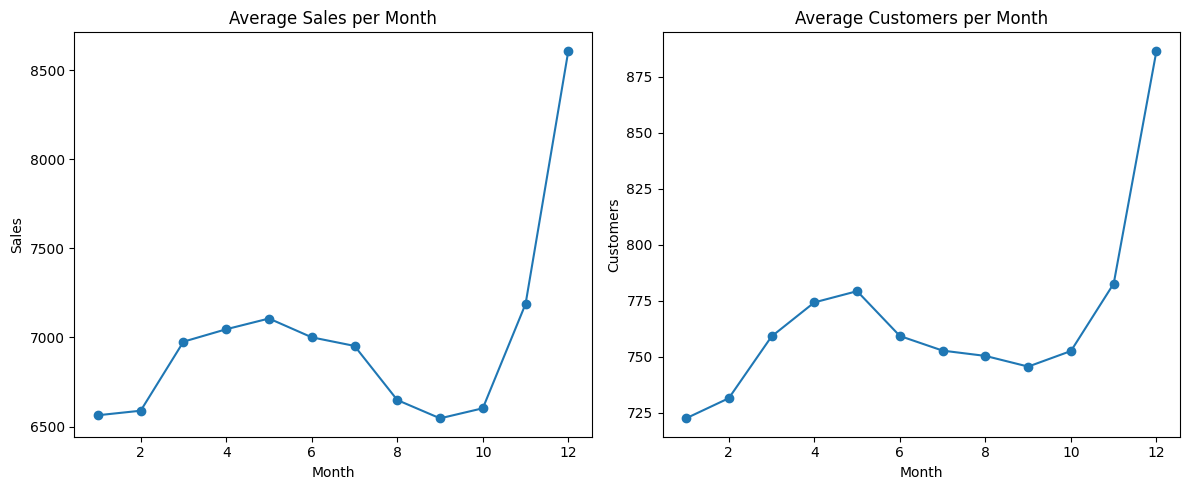

In [36]:
# Let's look at the average Sales and Customers per month
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sales_store_df.groupby('Month')['Sales'].mean().plot(marker='o')
plt.ylabel('Sales')
plt.xlabel('Month')
plt.title('Average Sales per Month')

plt.subplot(1, 2, 2)
sales_store_df.groupby('Month')['Customers'].mean().plot(marker='o')
plt.ylabel('Customers')
plt.xlabel('Month')
plt.title('Average Customers per Month')

plt.tight_layout()
plt.show()


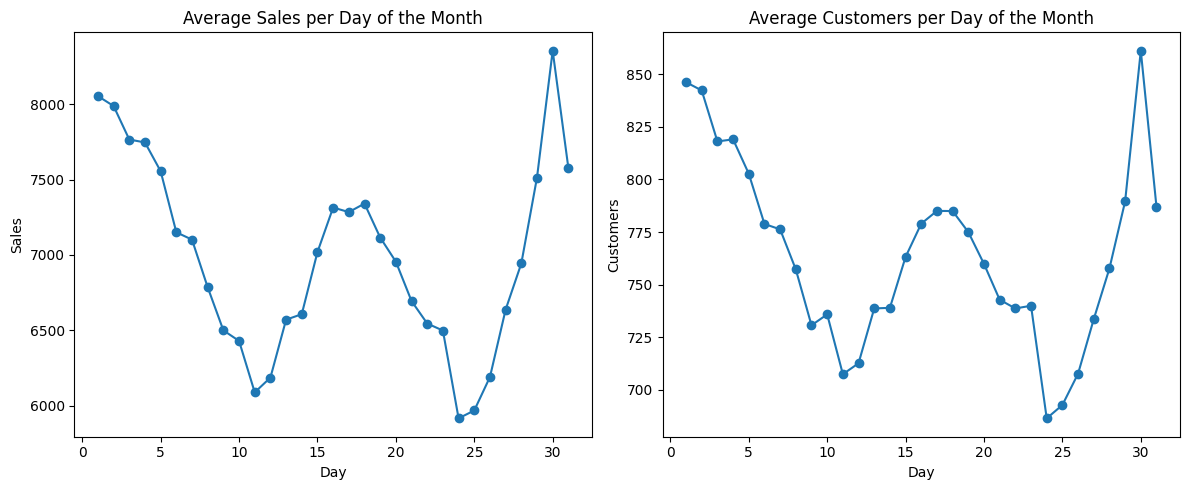

In [37]:
# Let's look at the average Sales and Customers per day of the month
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sales_store_df.groupby('Day')['Sales'].mean().plot(marker='o')
plt.ylabel('Sales')
plt.xlabel('Day')
plt.title('Average Sales per Day of the Month')

plt.subplot(1, 2, 2)
sales_store_df.groupby('Day')['Customers'].mean().plot(marker='o')
plt.ylabel('Customers')
plt.xlabel('Day')
plt.title('Average Customers per Day of the Month')

plt.tight_layout()
plt.show()


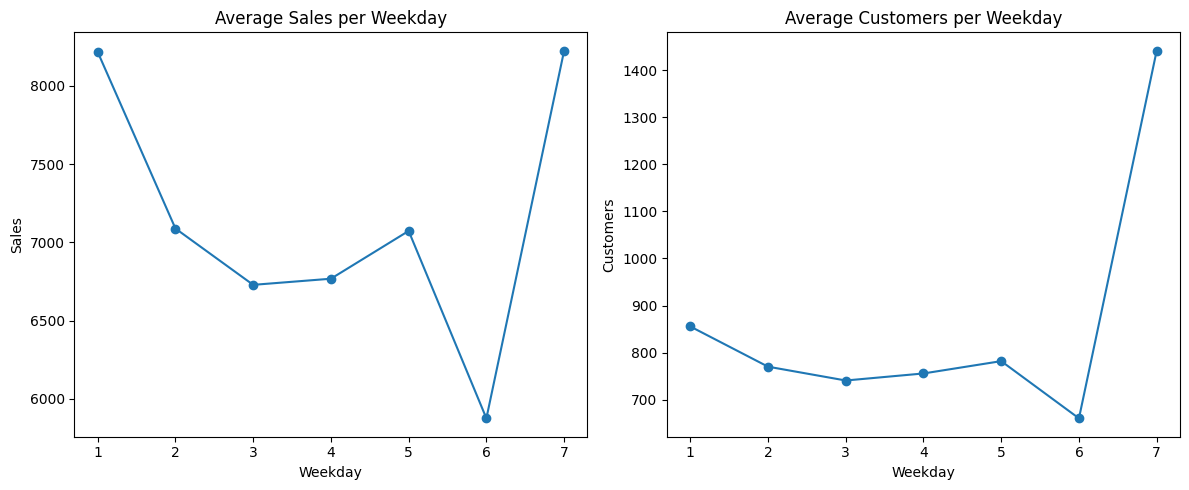

In [38]:
# Let's look at the average Sales and Customers per day of the week
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sales_store_df.groupby('DayOfWeek')['Sales'].mean().plot(marker='o')
plt.ylabel('Sales')
plt.xlabel('Weekday')
plt.title('Average Sales per Weekday')

plt.subplot(1, 2, 2)
sales_store_df.groupby('DayOfWeek')['Customers'].mean().plot(marker='o')
plt.ylabel('Customers')
plt.xlabel('Weekday')
plt.title('Average Customers per Weekday')

plt.tight_layout()
plt.show()

In [39]:
sales_store_df.groupby('Year')['Customers'].mean()

Year
2013    757.537292
2014    774.728739
2015    752.674864
Name: Customers, dtype: float64

In [40]:
sales_store_df.groupby('Year')['Sales'].sum()

Year
2013    2302876084
2014    2180804896
2015    1389499643
Name: Sales, dtype: int64

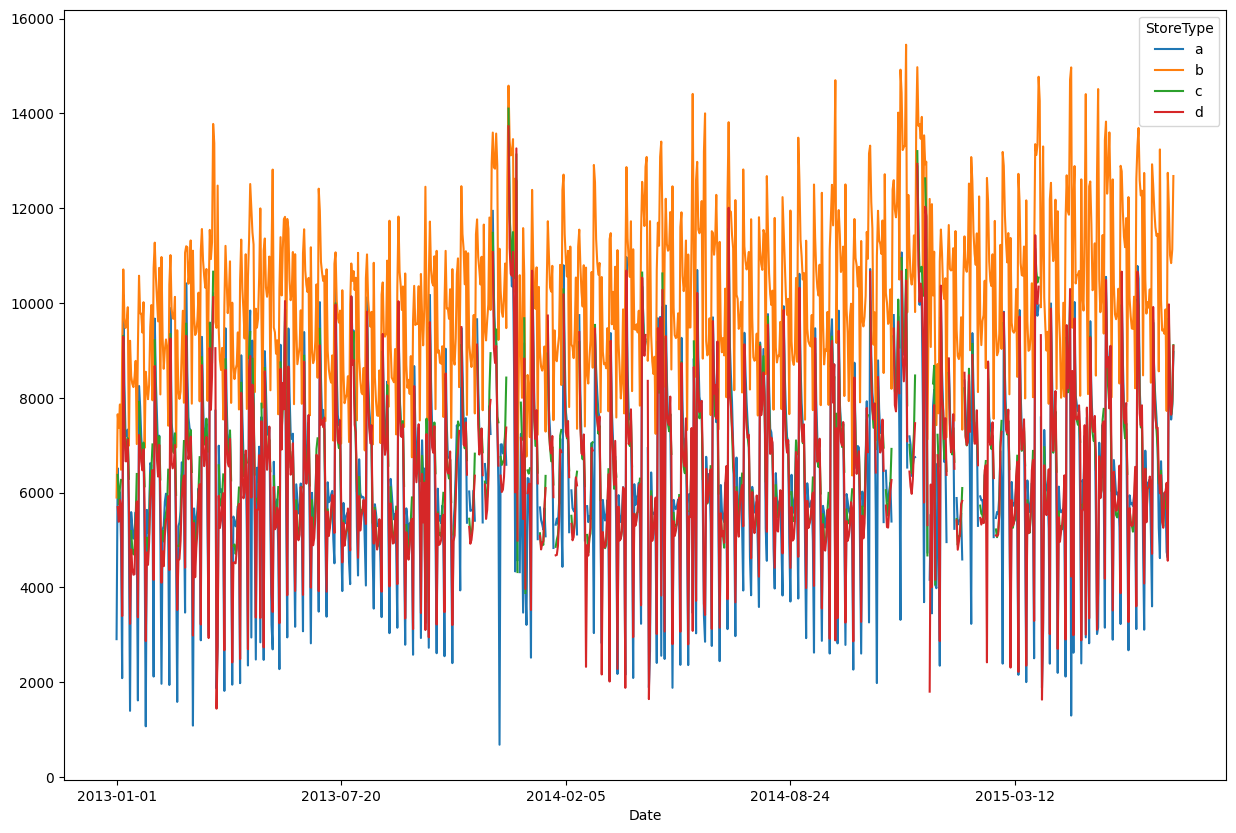

In [41]:

sales_store_df.groupby(['Date','StoreType'])['Sales'].mean().unstack().plot(figsize=(15,10))
plt.show()

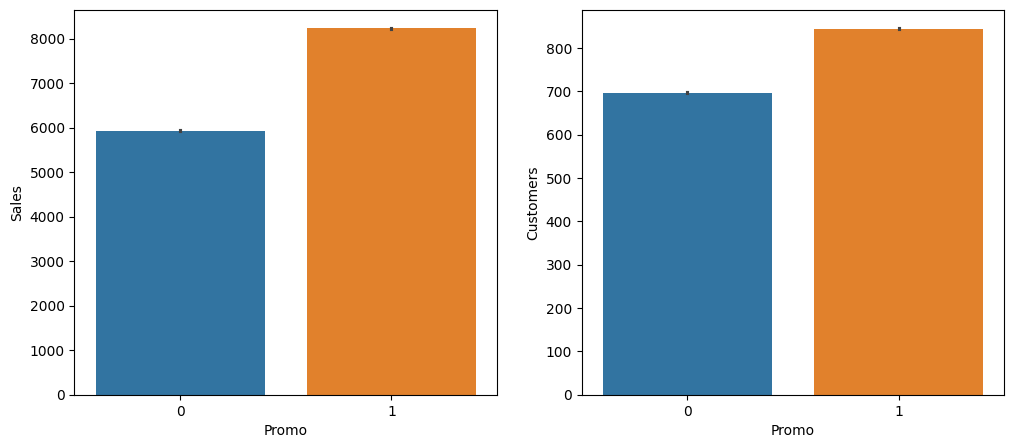

In [42]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x = 'Promo', y = 'Sales', data = sales_store_df, hue='Promo', legend=False)

plt.subplot(1, 2, 2)
sns.barplot(x = 'Promo', y = 'Customers', data = sales_store_df, hue='Promo', legend=False)
plt.show()

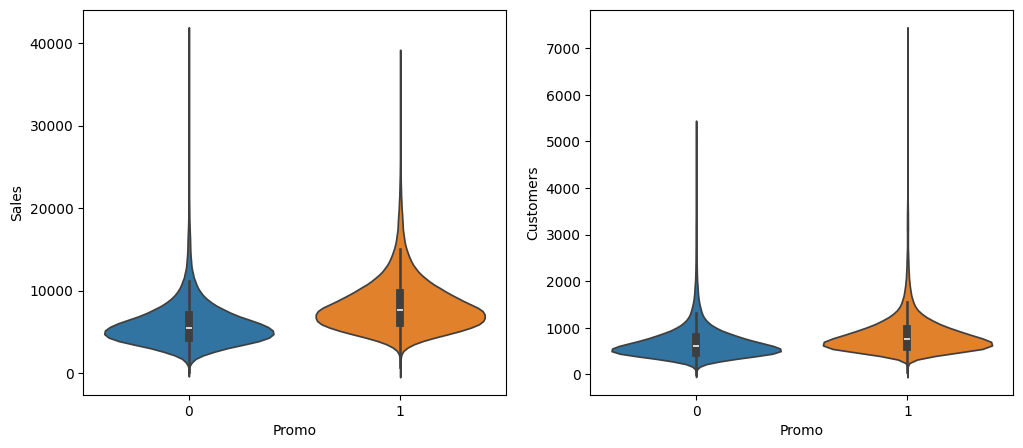

In [43]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.violinplot(x = 'Promo', y = 'Sales', data = sales_store_df, hue='Promo', legend=False)

plt.subplot(1, 2, 2)
sns.violinplot(x = 'Promo', y = 'Customers', data = sales_store_df, hue='Promo', legend=False)
plt.show()

# **Train Model**

In [44]:
!pip install --upgrade setuptools wheel
!pip install prophet
from prophet import Prophet

In [45]:

# using Facebook Profit to make predictions on specific Store
def sales_forcast(Store_ID,sales_df ,periods): #(specific store, data frame, periods in the future)

  sales_df = sales_df[sales_df['Store'] == Store_ID]
  sales_df = sales_df.rename(columns={'Date': 'ds', 'Sales': 'y'})
  sales_df = sales_df.sort_values(by='ds')

  # Create and fit the Prophet model
  model = Prophet()
  model.fit(sales_df)

  # Create a future dataframe for forecasting
  future = model.make_future_dataframe(periods=periods)

  # Make predictions
  forecast = model.predict(future)

  fig = model.plot(forecast, xlabel='Date', ylabel='Sales')
  figure2  = model.plot_components(forecast)
  fig.show()




19:56:39 - cmdstanpy - INFO - Chain [1] start processing
19:56:39 - cmdstanpy - INFO - Chain [1] done processing


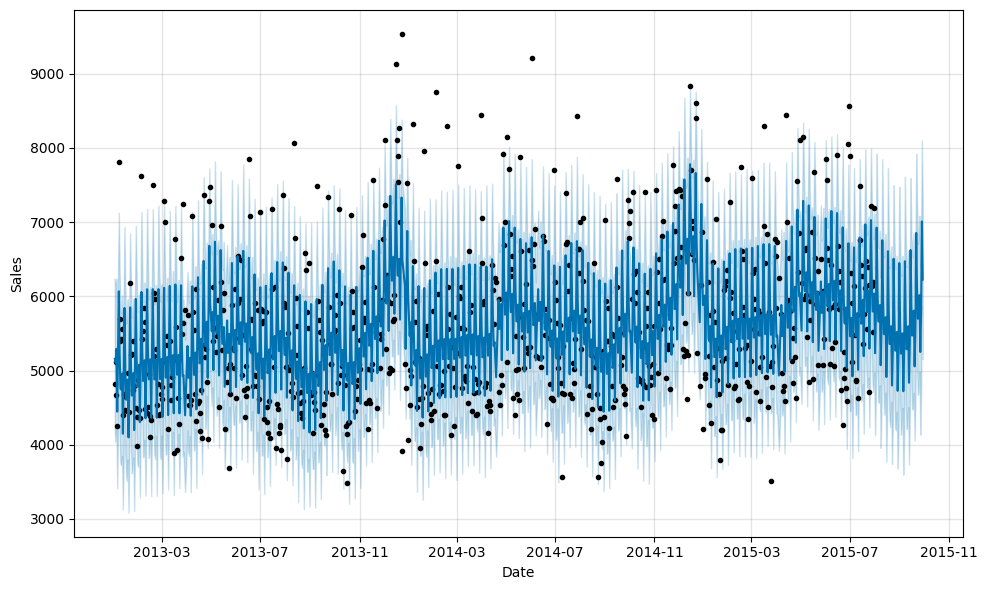

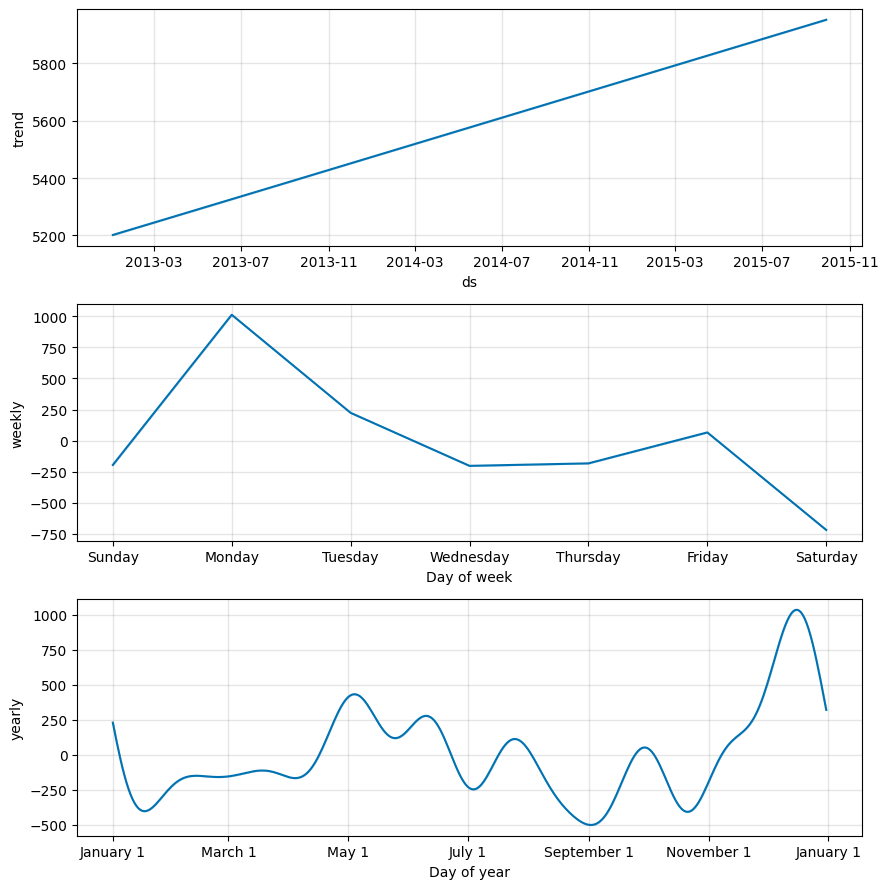

In [46]:
sales_forcast(10, sales_train_df, 60)

In [47]:
sales_store_df.head(2)

,Store,DayOfWeek,Date,Sales,Customers,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval,Year,Month,Day
0,1,5,2015-07-31,5263,555,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,0,2015,7,31
1,2,5,2015-07-31,6064,625,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct",2015,7,31


In [48]:
sales_train_df.StateHoliday.value_counts()

StateHoliday
0    731342
0    112140
a       694
b       145
c        71
Name: count, dtype: int64

In [49]:
sales_store_df.SchoolHoliday.value_counts()


SchoolHoliday
0    680935
1    163457
Name: count, dtype: int64

In [ ]:
state_holidays = sales_train_df[(sales_train_df.StateHoliday!=0) & (sales_train_df.StateHoliday!='0')  ].loc[:,'Date']
state_holidays.shape

(910,)

In [51]:
type(state_holidays.iloc[0])

    

str

In [52]:
state_holidays = pd.DataFrame({'ds': pd.to_datetime(state_holidays), 'holiday':'state_holiday'})
state_holidays

,ds,holiday
63559,2015-06-04,state_holiday
63560,2015-06-04,state_holiday
63609,2015-06-04,state_holiday
63611,2015-06-04,state_holiday
63614,2015-06-04,state_holiday
...,...,...
1016776,2013-01-01,state_holiday
1016827,2013-01-01,state_holiday
1016863,2013-01-01,state_holiday
1017042,2013-01-01,state_holiday


In [53]:
school_holidays = sales_train_df[sales_train_df.SchoolHoliday!=0].loc[:,'Date']
school_holidays.shape


(163457,)

In [54]:
school_holidays

0          2015-07-31
1          2015-07-31
2          2015-07-31
3          2015-07-31
4          2015-07-31
              ...    
1016776    2013-01-01
1016827    2013-01-01
1016863    2013-01-01
1017042    2013-01-01
1017190    2013-01-01
Name: Date, Length: 163457, dtype: object

In [55]:
school_holidays = pd.DataFrame({'ds': pd.to_datetime(school_holidays), 'holiday':'school_holiday'})
school_holidays

,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-31,school_holiday
2,2015-07-31,school_holiday
3,2015-07-31,school_holiday
4,2015-07-31,school_holiday
...,...,...
1016776,2013-01-01,school_holiday
1016827,2013-01-01,school_holiday
1016863,2013-01-01,school_holiday
1017042,2013-01-01,school_holiday


In [56]:
school_state_holidays = pd.concat((school_holidays, state_holidays))
school_state_holidays

,ds,holiday
0,2015-07-31,school_holiday
1,2015-07-31,school_holiday
2,2015-07-31,school_holiday
3,2015-07-31,school_holiday
4,2015-07-31,school_holiday
...,...,...
1016776,2013-01-01,state_holiday
1016827,2013-01-01,state_holiday
1016863,2013-01-01,state_holiday
1017042,2013-01-01,state_holiday


In [62]:
def sales_forcast_with_holidays(Store_ID, sales_df, holidays, periods):
  # Function that takes in the storeID and returns two date/sales columns in Prophet format
  # Format data to fit prophet 

  sales_df = sales_df[ sales_df['Store'] == Store_ID ]
  sales_df = sales_df[['Date', 'Sales']].rename(columns = {'Date': 'ds', 'Sales':'y'})
  sales_df = sales_df.sort_values('ds')
  
  model    = Prophet(holidays = holidays)
  model.fit(sales_df)
  future   = model.make_future_dataframe(periods = periods)
  forecast = model.predict(future)
  figure   = model.plot(forecast, xlabel='Date', ylabel='Sales')
  figure2  = model.plot_components(forecast)
  

20:02:34 - cmdstanpy - INFO - Chain [1] start processing
20:02:34 - cmdstanpy - INFO - Chain [1] done processing


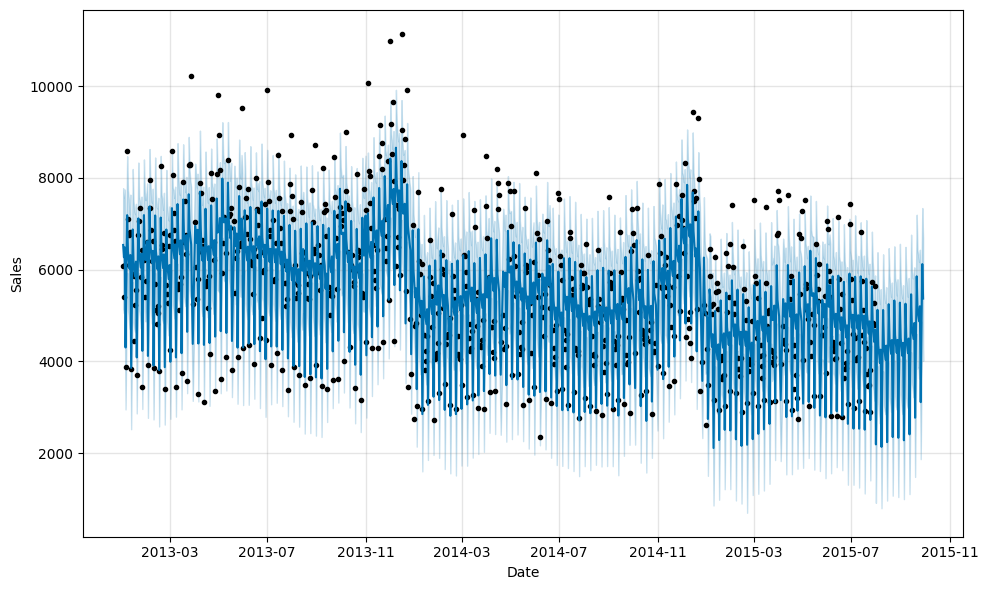

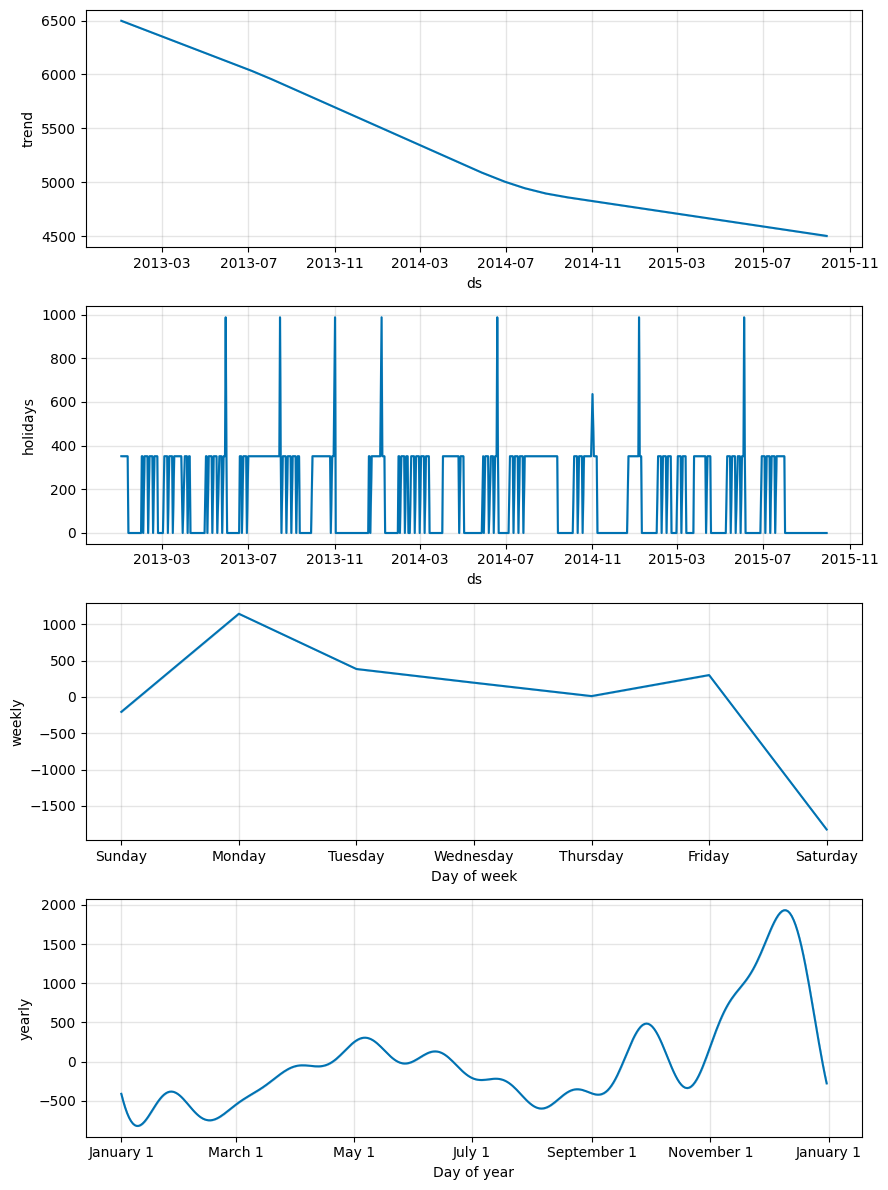

In [64]:
sales_forcast_with_holidays(6,sales_train_df, school_state_holidays,60)